In [1]:
import numpy as np
import h5py as h5
from multiprocessing import Pool
import torch
import pickle as pk
import sys, os




In [2]:
params_all = np.loadtxt('/projects/bdne/spandey3/halo_gotham/GOTHAM/prep_data/latin_hypercube_params.txt')
params_all.shape



(2000, 5)

In [3]:
# sims_per_gpu


In [4]:
# nsims_tot = 2000
# train_fac = 0.75
# val_fac = 0.175
# test_fac = 0.075

# n_gpus = 24
# sims_per_gpu = nsims_tot//n_gpus
# train_sims_per_gpu = int(train_fac * sims_per_gpu)
# val_sims_per_gpu = int(val_fac * sims_per_gpu)
# for ji in range(n_gpus):
#     id_train_start = ji*sims_per_gpu
#     id_train_end = id_train_start + train_sims_per_gpu

#     id_val_start = id_train_end
#     id_val_end = id_val_start + val_sims_per_gpu

#     id_test_start = id_val_end
#     id_test_end = id_train_start + sims_per_gpu
#     print(ji, id_test_start, id_test_end)
    


In [8]:
from tqdm import tqdm

nrand_sel_box = 8192
isfid = False
nsims_tot = 2000
train_fac = 0.75
val_fac = 0.175
# train_fac = 0.725
# val_fac = 0.2
test_fac = 0.075


# nrand_sel_box = 32768
# isfid = True
# nsims_tot = 20
# train_fac = 0.5
# val_fac = 0.5
# test_fac = 0.0


subsamp_ds = 4
n_gpus = 16
# n_gpus = 24

# subsamp_ds = 1
# n_gpus = 8


# subsamp_ds = 8
# n_gpus = 2

# subsamp_ds = 8
# n_gpus = 1

# subsamp_ds = 1
# n_gpus = 8

sims_per_gpu = nsims_tot//n_gpus
train_sims_per_gpu = int(train_fac * sims_per_gpu)
val_sims_per_gpu = int(val_fac * sims_per_gpu)


BoxSize = 1000.
grid = 32
grid_sbox = 8
nvocab = 1
DS_RES_POS_FAC = 1
MAS_type = 'CIC'
snapnum = 73
Mstar_cut = 12.7
# Mstar_cut = 13.3
add_space_token = False



ldir = '/work/hdd/bdne/spandey3/quijote_data/halo_gotham_data/LH'

params_all = np.loadtxt('/projects/bdne/spandey3/halo_gotham/GOTHAM/prep_data/latin_hypercube_params.txt')

def get_DMO_data(isim_fid, subsamp_ds=1, isfid=False):  
    if isfid:
        savefname_dmo_fields = f'{ldir}/DMO_fields_ng32/DMO_fields_grid_{grid_sbox}_fidcosmo_isim_{isim_fid}_nrandsubsel_{nrand_sel_box}_MAS_{MAS_type}_nsnaps_2.pkl'
    else: 
        savefname_dmo_fields = f'{ldir}/DMO_fields_ng32/DMO_fields_grid_{grid_sbox}_isim_{isim_fid}_nrandsubsel_{nrand_sel_box}_MAS_{MAS_type}_nsnaps_2.pkl'
    saved = pk.load(open(savefname_dmo_fields, 'rb'))
    dmo_fields = saved['dmo_fields_all']
    # try:
    rand_sel = saved['rand_sel']
    # except:
    #     import numpy as np
    #     np.random.seed(0)
    #     rand_sel = np.sort(np.random.randint(0, grid**3, nrand_sel_box)).astype(int)

    if subsamp_ds>1:
        # nsel = int(len(rand_sel)//subsamp_ds)
        dmo_fields = dmo_fields[::subsamp_ds,...]
        rand_sel = rand_sel[::subsamp_ds]
    return dmo_fields



def get_data_DMO_mat(isim_start, isim_end, subsamp_ds, isfid=False):
    dmo_fields_all = []
    for isim_fid in tqdm(range(isim_start, isim_end)):
        dmo_fields_i = get_DMO_data(isim_fid, subsamp_ds, isfid=isfid)
        dmo_fields_all.append(dmo_fields_i)
    
    dmo_fields_all = torch.moveaxis(torch.Tensor(np.concatenate(dmo_fields_all, axis=0)).to(torch.float16), -1, 1)

    return dmo_fields_all





In [9]:
# # sims_per_gpu, train_sims_per_gpu, val_sims_per_gpu 
# import numpy as np
# for isim_fid in range(2000):
#     try:
#         savefname_gals = f'{ldir}/halo_props_ng32_HRES/halo_props_snap_{snapnum}_grid_{nvocab//DS_RES_POS_FAC}_isim_{isim_fid}_nrandsubsel_{nrand_sel_box}_nvocab{nvocab}_spacetoken_{add_space_token}_xyzMvc_{Mstar_cut}.pkl'        
#         saved = pk.load(open(savefname_gals, 'rb'))
#     except:
#         print(isim_fid)
#         pass


In [9]:
sdir = '/work/hdd/bdne/spandey3/quijote_data/halo_gotham_data/process_split'
if isfid:
    savefname = f'{sdir}/SPLIT_DMO_DATA_fidcosmo_{n_gpus}_gpus_density3Dgrid_{grid_sbox}_isim_all_nrandsubsel_{int(nrand_sel_box/subsamp_ds)}.h5'
else:
    savefname = f'{sdir}/SPLIT_DMO_DATA_{n_gpus}_gpus_density3Dgrid_{grid_sbox}_isim_all_nrandsubsel_{int(nrand_sel_box/subsamp_ds)}.h5'
dtype = 'float16'
fo = h5.File(savefname, 'w')
try:
    # with h5.File(savefname, 'w') as fo:    
    for ji in range(n_gpus):
        id_train_start = ji*sims_per_gpu
        id_train_end = id_train_start + train_sims_per_gpu

        id_val_start = id_train_end
        id_val_end = id_val_start + val_sims_per_gpu

        dm_train = get_data_DMO_mat(id_train_start, id_train_end, subsamp_ds, isfid=isfid)
        dm_val = get_data_DMO_mat(id_val_start, id_val_end, subsamp_ds, isfid=isfid)

        fo.create_dataset(f'dm_train_dev_{ji}', data=dm_train)
        fo.create_dataset(f'dm_val_dev_{ji}', data=dm_val)

    fo.create_dataset('grid', data=grid_sbox)
    fo.close()
except:
    fo.close()




100%|██████████| 21/21 [00:07<00:00,  2.76it/s]


In [9]:
def get_gal_data(isim_fid, subsamp_ds=1, isfid=False):    
    import numpy as np
    if isfid:
        savefname_gals = f'{ldir}/halo_props_flow_ng32/halo_props_snap_{snapnum}_grid_{nvocab//DS_RES_POS_FAC}_fidcosmo_isim_{isim_fid}_nrandsubsel_{nrand_sel_box}_xyzMvc_{Mstar_cut}.pkl'        
    else:
        savefname_gals = f'{ldir}/halo_props_flow_ng32/halo_props_snap_{snapnum}_grid_{nvocab//DS_RES_POS_FAC}_isim_{isim_fid}_nrandsubsel_{nrand_sel_box}_xyzMvc_{Mstar_cut}.pkl'        
    saved = pk.load(open(savefname_gals, 'rb'))
    story_full = saved['story_full']

    if subsamp_ds>1:
        # nsel = int(len(rand_sel)/subsamp_ds)
        story_full = story_full[::subsamp_ds,...]
        # rand_sel = rand_sel[:nsel]
        

    params = params_all[isim_fid][None,:]
    # params_repeated = np.repeat(params, len(rand_sel), axis=0)
    params_repeated = np.repeat(params, story_full.shape[0], axis=0)    
    return params_repeated, story_full

def get_data_gal_mat(isim_start, isim_end, subsamp_ds, pad_token, isfid=False):
    params_repeated_all, story_full_all = [], []
    for isim_fid in tqdm(range(isim_start, isim_end)):
        params_repeated_i, story_full_i = get_gal_data(isim_fid, subsamp_ds, isfid=isfid)
        params_repeated_all.append(params_repeated_i)
        story_full_all.append(story_full_i)
    
    params_repeated_all = np.concatenate(params_repeated_all, axis=0)
    story_full_all = np.concatenate(story_full_all, axis=0)

    params_all = torch.tensor(params_repeated_all).to(torch.float16)
    
    return story_full_all, params_all




In [10]:
if isfid:
    savefname_gals = f'{ldir}/halo_props_flow_ng32//halo_props_snap_{snapnum}_grid_{nvocab//DS_RES_POS_FAC}_fidcosmo_isim_{0}_nrandsubsel_{nrand_sel_box}_xyzMvc_{Mstar_cut}.pkl'        
else:
    savefname_gals = f'{ldir}/halo_props_flow_ng32//halo_props_snap_{snapnum}_grid_{nvocab//DS_RES_POS_FAC}_isim_{0}_nrandsubsel_{nrand_sel_box}_xyzMvc_{Mstar_cut}.pkl'            

saved = pk.load(open(savefname_gals, 'rb'))
pad_token, max_sentence_length = saved['pad_token'], saved['max_sentence_length']

print(pad_token, max_sentence_length)

sdir = '/work/hdd/bdne/spandey3/quijote_data/halo_gotham_data/process_split'
if isfid:
    savefname = f'{sdir}/FLOW_SPLIT_HALO_DATA_fidcosmo_{n_gpus}_gpus_isim_all_nrandsubsel_{int(nrand_sel_box/subsamp_ds)}_grid_{nvocab//DS_RES_POS_FAC}_xyzMvc_{Mstar_cut}.h5'
else:
    savefname = f'{sdir}/FLOW_SPLIT_HALO_DATA_{n_gpus}_gpus_isim_all_nrandsubsel_{int(nrand_sel_box/subsamp_ds)}_grid_{nvocab//DS_RES_POS_FAC}_xyzMvc_{Mstar_cut}.h5'

dtype = 'float16'
fo = h5.File(savefname, 'w')
for ji in range(n_gpus):
    id_train_start = ji*sims_per_gpu
    id_train_end = id_train_start + train_sims_per_gpu

    id_val_start = id_train_end
    id_val_end = id_val_start + val_sims_per_gpu

    story_train, params_train = get_data_gal_mat(id_train_start, id_train_end, subsamp_ds, pad_token, isfid=isfid)
    story_val, params_val = get_data_gal_mat(id_val_start, id_val_end, subsamp_ds, pad_token, isfid=isfid)        

    fo.create_dataset(f'story_train_dev_{ji}', data=story_train)
    fo.create_dataset(f'params_train_dev_{ji}', data=params_train)

    fo.create_dataset(f'story_val_dev_{ji}', data=story_val)
    fo.create_dataset(f'params_val_dev_{ji}', data=params_val)

fo.create_dataset('pad_token', data=pad_token)
fo.create_dataset('max_sentence_length', data=max_sentence_length)
fo.close()






-1.0 600


100%|██████████| 21/21 [00:04<00:00,  4.30it/s]


In [28]:
import h5py as h5
jdev = 8
fname = '/work/hdd/bdne/spandey3/quijote_data/halo_gotham_data/process_split/SPLIT_HALO_DATA_24_gpus_isim_all_nrandsubsel_8192_grid_16_nvocab64_spacetoken_False_xMv1Dc_12.7.h5'
df = h5.File(fname, 'r')
y_train = df[f'y_train_dev_{jdev}'][:]
df.close()




In [21]:
import h5py as h5
# jdev = 5
fname = '/work/hdd/bdne/spandey3/quijote_data/halo_gotham_data/process_split/SPLIT_DMO_DATA_24_gpus_density3Dgrid_8_isim_all_nrandsubsel_8192.h5'
df = h5.File(fname, 'r')
dmf_train = df[f'dm_train_dev_{jdev}'][:]
df.close()



In [22]:
import matplotlib.pyplot as pl
%matplotlib inline


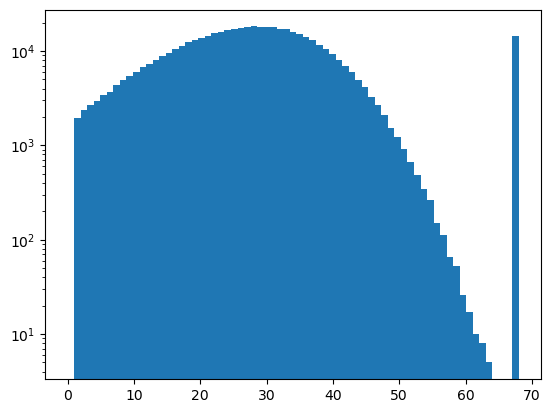

In [29]:
# x_train.shape
pl.figure()
_ = pl.hist(y_train[:,0], bins=69, range=(0,68))

pl.yscale('log')






In [ ]:
import h5py as h5
import numpy as np
sdir = '/work/hdd/bdne/spandey3/quijote_data/halo_gotham_data/process_split'
savefname = f'{sdir}/SPLIT_DMO_DATA_{16}_gpus_density3Dgrid_{8}_isim_all_nrandsubsel_{8192}.h5'
# dist.barrier()
rank = 0
ds_fac_here = 4
with h5.File(savefname, 'r') as f:
    # dm_train_gpu = torch.tensor(f[f'dm_train_dev_{rank}'][:][::ds_fac_here]).to(ptdtype).to(device_id, non_blocking=True)
    # dm_val_gpu = torch.tensor(f[f'dm_val_dev_{rank}'][:][::ds_fac_here]).to(ptdtype).to(device_id, non_blocking=True)
    # print(f[f'dm_train_dev_{rank}'][:].shape)
    ind_all_train = np.arange(f[f'dm_train_dev_{rank}'][:].shape[0])
    ind_all_val = np.arange(f[f'dm_val_dev_{rank}'][:].shape[0])
    np.random.seed(0)
    ind_all_train = np.random.permutation(ind_all_train)
    ind_all_val = np.random.permutation(ind_all_val)
    ind_sel_train = ind_all_train[::ds_fac_here]
    ind_sel_val = ind_all_train[::ds_fac_here]
    # grid_size = int(f['grid'][()])
f.close()
# dist.barrier()



In [4]:
print(ind_all_train_perm)




[400219 549425 536055 ... 117952 435829 305711]


In [ ]:
# # load the DMO data and save every dsth field:
# ldir = '/work/hdd/bdne/spandey3/quijote_data/halo_gotham_data/process_split'
# loadfname = f'{ldir}/SPLIT_DMO_DATA_{n_gpus}_gpus_density3Dgrid_{grid}_isim_all_nrandsubsel_{int(nrand_sel_box/subsamp_ds)}.h5'



# dtype = 'float16'
# fo = h5.File(savefname, 'w')
# # with h5.File(savefname, 'w') as fo:    
# for ji in range(n_gpus):
#     id_train_start = ji*sims_per_gpu
#     id_train_end = id_train_start + train_sims_per_gpu

#     id_val_start = id_train_end
#     id_val_end = id_val_start + val_sims_per_gpu

#     dm_train = get_data_DMO_mat(id_train_start, id_train_end, subsamp_ds)
#     dm_val = get_data_DMO_mat(id_val_start, id_val_end, subsamp_ds)        

#     fo.create_dataset(f'dm_train_dev_{ji}', data=dm_train)
#     fo.create_dataset(f'dm_val_dev_{ji}', data=dm_val)

# fo.create_dataset('grid', data=grid_sbox)
# fo.close()




In [2]:
import h5py as h5
fname = '/work/hdd/bdne/spandey3/quijote_data/halo_gotham_data/process_split/SPLIT_DMO_DATA_16_gpus_density3Dgrid_8_isim_all_nrandsubsel_8192.h5'
df = h5.File(fname, 'r')
print(df.keys())
df.close()



<KeysViewHDF5 ['dm_train_dev_0', 'dm_train_dev_1', 'dm_train_dev_10', 'dm_train_dev_11', 'dm_train_dev_12', 'dm_train_dev_13', 'dm_train_dev_14', 'dm_train_dev_15', 'dm_train_dev_2', 'dm_train_dev_3', 'dm_train_dev_4', 'dm_train_dev_5', 'dm_train_dev_6', 'dm_train_dev_7', 'dm_train_dev_8', 'dm_train_dev_9', 'dm_val_dev_0', 'dm_val_dev_1', 'dm_val_dev_10', 'dm_val_dev_11', 'dm_val_dev_12', 'dm_val_dev_13', 'dm_val_dev_14', 'dm_val_dev_15', 'dm_val_dev_2', 'dm_val_dev_3', 'dm_val_dev_4', 'dm_val_dev_5', 'dm_val_dev_6', 'dm_val_dev_7', 'dm_val_dev_8', 'dm_val_dev_9', 'grid']>


In [8]:
import matplotlib.pyplot as pl
%matplotlib inline


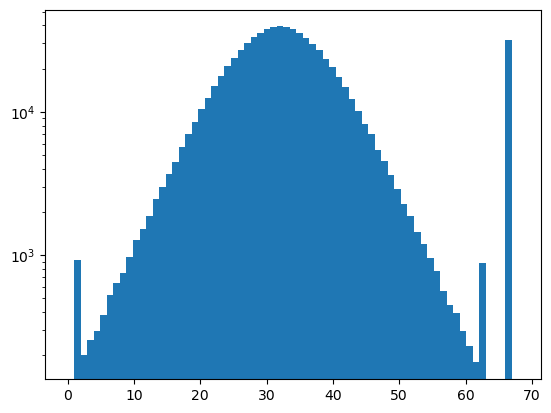

In [20]:
# x_train.shape
pl.figure()
_ = pl.hist(x_train[:,5], bins=69, range=(0,68))

pl.yscale('log')




In [61]:
# x_train[313,:]
indp = np.where(x_train[:,-8] == 68)[0]


In [52]:
xall = (np.linspace(0, BoxSize/grid, nvocab + 1))
xarray = 0.5 * (xall[1:] + xall[:-1])
yarray = np.copy(xarray)
zarray = np.copy(xarray)

prop_min = np.array([7.5, 26, 26, 26, -0.5])
prop_max = np.array([11.5, 30, 30, 30, 0.5])

bins_digitize = np.linspace(-1e-3, 1, nvocab)
bins_digitize = np.insert(bins_digitize, 0, -1)
delta_bin = bins_digitize[5] - bins_digitize[4]


In [71]:
pos_infer_all = []
prop_infer_all = []

dim_prop = 5
dim_pos = 3
ntokens_per_halo = 8
# jx, jy, jz = 0, 5, 2
# jx, jy, jz = 0, 5, 0
# for jx in range(grid):
#     for jy in range(grid):
#         for jz in range(grid):
sentence_here = x_train[indp[4],:]
ind_start_token = np.where(sentence_here == start_token)[0]
if end_token in sentence_here:
    ind_end_token = np.where(sentence_here == end_token)[0]
    Nhalos_here = ((ind_end_token - ind_start_token - 1) / ntokens_per_halo)[0]
    if (int(Nhalos_here) - Nhalos_here) != 0:
        print('Nhalos_here is not an integer')
    else:
        if Nhalos_here > 0:
            for jh in range(int(Nhalos_here)):
                coord_x = (xarray[sentence_here[ind_start_token + jh*ntokens_per_halo + 1]] + (BoxSize/grid)*0) % BoxSize
                coord_y = (yarray[sentence_here[ind_start_token + jh*ntokens_per_halo + 2]] + (BoxSize/grid)*0) % BoxSize
                coord_z = (zarray[sentence_here[ind_start_token + jh*ntokens_per_halo + 3]] + (BoxSize/grid)*0) % BoxSize


                pos_infer_all.append([coord_x, coord_y, coord_z])
                prop_all = np.zeros(dim_prop)
                for jp in range(dim_prop):
                    # noise_val = np.random.uniform(-delta_bin/2, delta_bin/2)
                    noise_val = 0
                    bin_val_jp = sentence_here[ind_start_token + jh*ntokens_per_halo + 4 + jp]
                    prop_all[jp] = prop_min[jp] + (prop_max[jp] - prop_min[jp]) * (bins_digitize[bin_val_jp] + noise_val)
                prop_infer_all.append(prop_all)

pos_infer_all = np.array(pos_infer_all)
prop_infer_all = np.array(prop_infer_all)



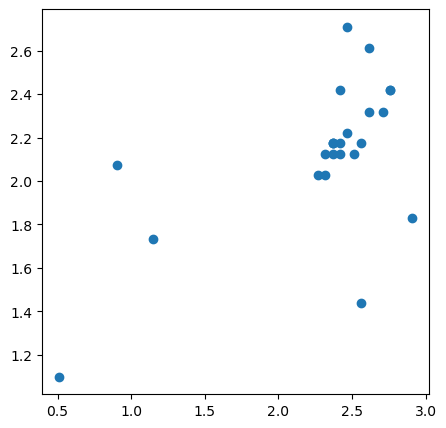

In [72]:
pl.figure(figsize=(5,5))
pl.scatter(pos_infer_all[:,0], pos_infer_all[:,1])


In [85]:
# Ndevices = 4
# sdir = '/work/hdd/bdne/spandey3/camels_tng/gotham_data/process_split'
# savefname = f'{sdir}/SPLIT_DATA_{Ndevices}_gpus_nspersim_subhalo_density3Dgrid_{grid_sbox}_isim_all_nrandsubsel_{int(nrand_sel_box/subsamp_ds)}_nvocab{nvocab}_wSDSS_photometry_gri_velx_hres_0.h5'
# fo1 = h5.File(savefname, 'r')
# savefname = f'{sdir}/SPLIT_DATA_{Ndevices}_gpus_nspersim_subhalo_density3Dgrid_{grid_sbox}_isim_all_nrandsubsel_{int(nrand_sel_box/subsamp_ds)}_nvocab{nvocab}_wSDSS_photometry_gri_velx_hres.h5'
# fo = h5.File(savefname, 'w')
# fo.create_dataset('nvocab_total', data=nvocab_total)
# fo.create_dataset('grid', data=grid_sbox)
# fo.create_dataset('start_token', data=start_token)
# fo.create_dataset('pad_token', data=pad_token)
# fo.create_dataset('end_token', data=end_token)
# fo.create_dataset('max_sentence_length', data=max_sentence_length)


# for ji in range(4):
#     fo.create_dataset(f'x_train_dev_{ji}', data=fo1[f'x_train_dev_{ji}'][:])
#     fo.create_dataset(f'dm_train_dev_{ji}', data=torch.moveaxis(torch.Tensor(fo1[f'dm_train_dev_{ji}'][:]), -1, 1))
#     fo.create_dataset(f'params_train_dev_{ji}', data=fo1[f'params_train_dev_{ji}'][:])
#     fo.create_dataset(f'mask_train_dev_{ji}', data=fo1[f'mask_train_dev_{ji}'][:])
#     fo.create_dataset(f'y_train_dev_{ji}', data=fo1[f'y_train_dev_{ji}'][:])

#     fo.create_dataset(f'x_val_dev_{ji}', data=fo1[f'x_val_dev_{ji}'][:])
#     fo.create_dataset(f'dm_val_dev_{ji}', data=torch.moveaxis(torch.Tensor(fo1[f'dm_val_dev_{ji}'][:]), -1, 1))
#     fo.create_dataset(f'params_val_dev_{ji}', data=fo1[f'params_val_dev_{ji}'][:])
#     fo.create_dataset(f'mask_val_dev_{ji}', data=fo1[f'mask_val_dev_{ji}'][:])
#     fo.create_dataset(f'y_val_dev_{ji}', data=fo1[f'y_val_dev_{ji}'][:])
    
# fo.close()
# fo1.close()


In [87]:
# ji = 0
# sdir = '/work/hdd/bdne/spandey3/camels_tng/gotham_data/process_split'
# savefname = f'{sdir}/SPLIT_DATA_{Ndevices}_gpus_nspersim_subhalo_density3Dgrid_{grid_sbox}_isim_all_nrandsubsel_{int(nrand_sel_box/subsamp_ds)}_nvocab{nvocab}_wSDSS_photometry_gri_velx_hres.h5'
# fo2 = h5.File(savefname, 'r')
# print(fo2[f'dm_val_dev_{ji}'][:].shape)
# fo2.close()


(2752, 30, 32, 32, 32)


In [83]:
# /work/hdd/bdne/spandey3/camels_tng/gotham_data/process_split/SPLIT_DATA_4_gpus_nspersim_subhalo_density3Dgrid_32_isim_all_nrandsubsel_32_nvocab128_wSDSS_photometry_gri_velx_hres.h5

# /work/hdd/bdne/spandey3/camels_tng/gotham_data/process_split/SPLIT_DATA_4_gpus_nspersim_subhalo_density3Dgrid_32_isim_all_nrandsubsel_64_nvocab64_wSDSS_photometry_gri_velx_hres.h5
# nvocab_total
# ji = 0
# torch.moveaxis(torch.Tensor(fo1[f'dm_train_dev_{ji}'][:]), -1, 1).shape



torch.Size([11968, 30, 32, 32, 32])